In [2]:
import numpy as np
from tensorflow import keras
import matplotlib.pyplot as plt

In [3]:
# 读入MNIST数据集
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [4]:
help(keras.datasets.mnist.load_data)

Help on function load_data in module keras.src.datasets.mnist:

load_data(path='mnist.npz')
    Loads the MNIST dataset.
    
    This is a dataset of 60,000 28x28 grayscale images of the 10 digits,
    along with a test set of 10,000 images.
    More info can be found at the
    [MNIST homepage](http://yann.lecun.com/exdb/mnist/).
    
    Args:
        path: path where to cache the dataset locally
            (relative to `~/.keras/datasets`).
    
    Returns:
        Tuple of NumPy arrays: `(x_train, y_train), (x_test, y_test)`.
    
    **`x_train`**: `uint8` NumPy array of grayscale image data with shapes
      `(60000, 28, 28)`, containing the training data. Pixel values range
      from 0 to 255.
    
    **`y_train`**: `uint8` NumPy array of digit labels (integers in range 0-9)
      with shape `(60000,)` for the training data.
    
    **`x_test`**: `uint8` NumPy array of grayscale image data with shapes
      `(10000, 28, 28)`, containing the test data. Pixel values range
  

In [5]:
# 查看训练集的形状
x_train.shape, y_train.shape

((60000, 28, 28), (60000,))

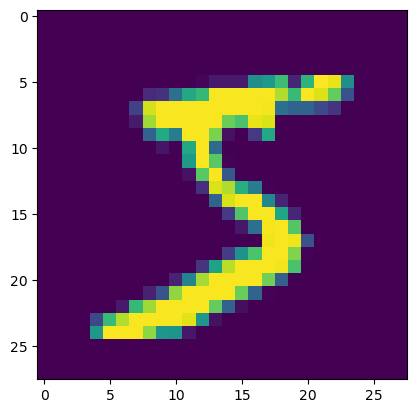

In [6]:
# 显示图片
plt.imshow(x_train[0])

In [7]:
y_train[0]

5

In [8]:
# 输入层
input_shape = (28, 28, 1)

# 输出层
num_classes = 10

In [9]:
#  数据预处理
print(x_train.shape)

(60000, 28, 28)


In [10]:
x_train[1]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,  51, 159, 253, 159,  50,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  48, 238, 252, 252, 252, 237,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  

In [11]:
# (1)数据标准化, 将图像缩放到[0, 1] 范围
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255

In [12]:
print(x_train[2])

[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.    

In [13]:
x_train.shape, x_test.shape

((60000, 28, 28), (10000, 28, 28))

In [14]:
# (2) 将数据形状改为(28, 28, 1)
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)
print("x_train.shape", x_train.shape)
print(x_train.shape[0], "train samples")
print(x_test.shape[0], "test samples")

x_train.shape (60000, 28, 28, 1)
60000 train samples
10000 test samples


In [15]:
# 输出y_train
y_train

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

In [16]:
# (3) 将类别标签转换为onehot编码, 为将向量转换为二维矩阵
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)
y_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.]])

In [21]:
# 定义学习框架
# 模型参数的定义
num_filters_1 = 32
num_filters_2 = 64
num_strides = 1
kernel_size = (3, 3)

In [22]:
model = keras.Sequential(
    [
        keras.Input(shape=input_shape),  # 输入层
        
        # 第一次卷积与池化过程
        keras.layers.Conv2D(
            filters = num_filters_1,
            kernel_size = kernel_size,
            strides = num_strides,
            padding = 'valid',
            activation = 'relu',
            use_bias = True, # 偏置项
            bias_initializer = keras.initializers.Zeros()
        ),
        
        # 最大池化层
        keras.layers.MaxPooling2D(
            pool_size = (2, 2),
            strides = None,
            padding = 'valid'
        ),
        
        # 第二吃卷积与池化过程
        keras.layers.Conv2D(
            filters = num_filters_2,
            kernel_size = kernel_size,
            strides = num_strides,
            padding = 'valid',
            activation = 'relu',
        ),
        keras.layers.MaxPooling2D(
            pool_size = (2, 2),
            strides = None,
            padding = 'valid'
        ),
        # 扁平化输出
        keras.layers.Flatten(),
        
        # dropput层
        keras.layers.Dropout(rate = 0.5),
        
        # 全连接层
        keras.layers.Dense(
            units = num_classes,
            activation = 'softmax',
        ),
    ]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
# 训练模型
model.compile(
    # 损失函数
    loss="categorical_crossentropy",
    optimizer = "adam",
    metrics = ["accuracy"]
)

# batch的大小
batch_size = 128

epochs = 10

hist = model.fit(
    x_train,
    y_train,
    batch_size = batch_size,
    epochs = epochs,
    validation_split = 0.1,
)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.7659 - loss: 0.7554 - val_accuracy: 0.9798 - val_loss: 0.0823
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9621 - loss: 0.1220 - val_accuracy: 0.9832 - val_loss: 0.0573
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9726 - loss: 0.0894 - val_accuracy: 0.9868 - val_loss: 0.0478
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9782 - loss: 0.0704 - val_accuracy: 0.9883 - val_loss: 0.0455
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.9802 - loss: 0.0633 - val_accuracy: 0.9892 - val_loss: 0.0380
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.9818 - loss: 0.0563 - val_accuracy: 0.9908 - val_loss: 0.0365
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.9837 - loss: 0.0519 - val_accuracy: 0.9902 - val_loss: 0.0330
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.9845 - loss: 0.0477 - val_accu

In [25]:
# 7.评价模型
score = model.evaluate(x_test, y_test, verbose=0)
print("Test loss:", score[0])
print("Test accuracy:", score[1])
print(score)

Test loss: 0.028600674122571945
Test accuracy: 0.9911999702453613
[0.028600674122571945, 0.9911999702453613]


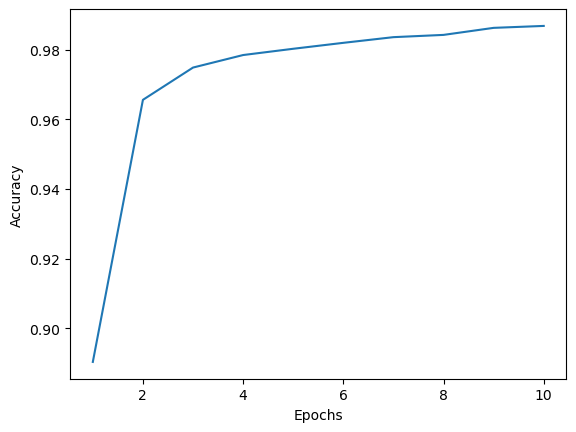

In [26]:
plt.plot(range(1, epochs +1), hist.history["accuracy"])
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

In [27]:
hist.history

{'accuracy': [0.8903889060020447,
  0.9655740857124329,
  0.9748333096504211,
  0.978425920009613,
  0.980222225189209,
  0.981925904750824,
  0.9835555553436279,
  0.9842036962509155,
  0.9862222075462341,
  0.9867777824401855],
 'loss': [0.3639557659626007,
  0.11373066902160645,
  0.08253861963748932,
  0.06924739480018616,
  0.06306149065494537,
  0.05649146810173988,
  0.05285896733403206,
  0.04844404384493828,
  0.04428236186504364,
  0.04169022664427757],
 'val_accuracy': [0.9798333048820496,
  0.9831666946411133,
  0.9868333339691162,
  0.9883333444595337,
  0.9891666769981384,
  0.9908333420753479,
  0.9901666641235352,
  0.9919999837875366,
  0.9906666874885559,
  0.9916666746139526],
 'val_loss': [0.08225226402282715,
  0.05727643147110939,
  0.04781203344464302,
  0.04545282572507858,
  0.03799005225300789,
  0.036489564925432205,
  0.03302581235766411,
  0.033015940338373184,
  0.03391239792108536,
  0.03141700103878975]}

In [28]:
# 预测结果
prediction = model.predict(x_test[:1])
print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
[[1.61518798e-08 6.77521772e-09 1.36822655e-05 1.07433798e-05
  5.44134356e-12 3.06006864e-09 3.29458801e-15 9.99963164e-01
  5.76217651e-08 1.23335421e-05]]


In [29]:
# 显示预测标签结果
list(prediction[0]).index((prediction[0].max()))

7